# Analyzing Software Engineering as a Lifecycle Process
- Modeling and concept mapping
- State extraction
- Utility experiment


## 1. Load DuckDB and build weekly counts


Dataset: Vibe-Trading
DuckDB: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\Vibe-Trading.duckdb
OCEL2: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\Vibe-Trading.sqlite
Closed event type id: 2076


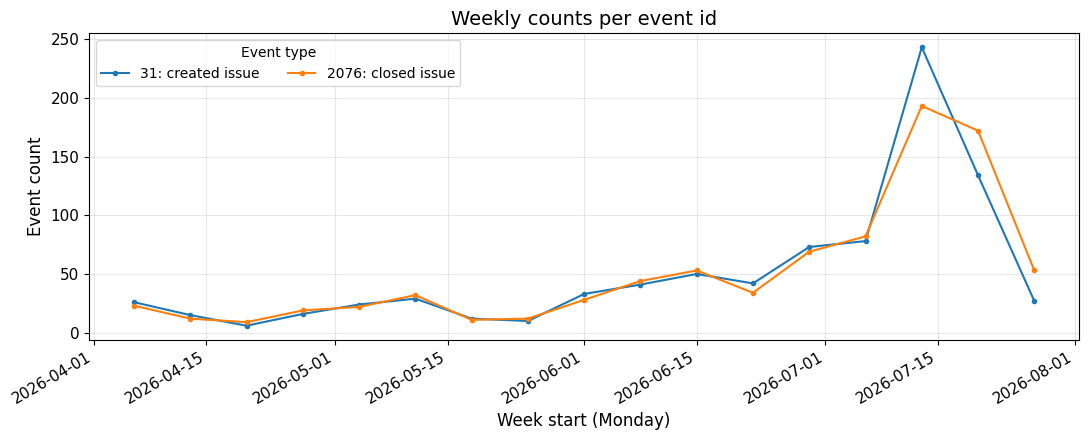

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\Vibe-Trading\weekly_open_closed_summary.csv


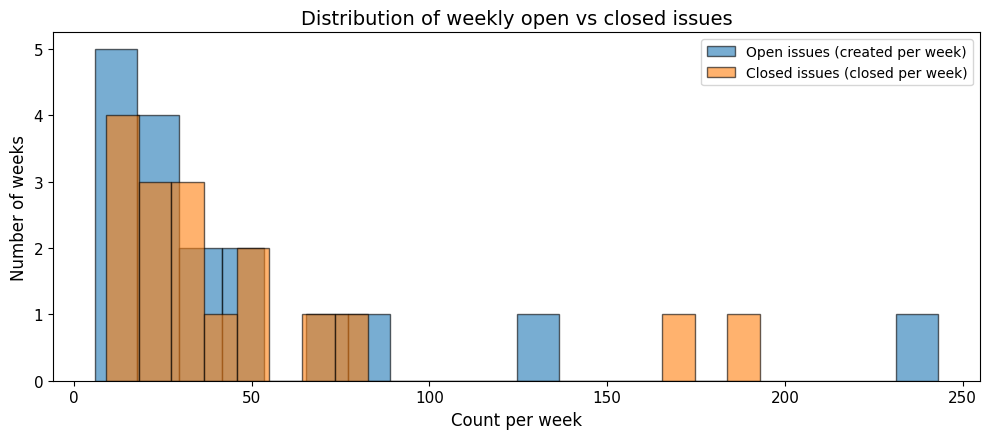

,Open issues (weekly created),Closed issues (weekly closed)
count,17.00,17.00
mean,50.53,51.06
std,58.97,53.84
min,6.00,9.00
25%,16.00,19.00
50%,29.00,32.00
75%,50.00,53.00
max,243.00,193.00


In [1]:
from pathlib import Path

from functions.configs import load_dataset_config
from functions.data_loading import (
    build_weekly_issue_counts,
    load_events_per_obj,
    load_objects_attributes,
)
from functions.plotting_anomaly import (
    plot_weekly_event_counts,
    plot_weekly_open_vs_closed_histogram,
    weekly_open_closed_summary_table,
)

# The only dataset-specific line in this notebook.
cfg = load_dataset_config("Vibe-Trading")

cfg.tables_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_dir.mkdir(parents=True, exist_ok=True)

print("Dataset:", cfg.dataset_name)
print("DuckDB:", cfg.duckdb_path)
print("OCEL2:", cfg.sqlite_path)
print("Closed event type id:", cfg.closed_event_type_id)

eventsPerobj_df = load_events_per_obj(cfg)
objects_attributes = load_objects_attributes(cfg)
weekly = build_weekly_issue_counts(eventsPerobj_df, cfg)
plot_weekly_event_counts(weekly, cfg)
summary_table = weekly_open_closed_summary_table(weekly, cfg)
plot_weekly_open_vs_closed_histogram(weekly, cfg)
summary_table


## 2. Rolling IQR + lexicon state extraction


In [2]:
from functions.anomaly_pipeline import run_anomaly_state_extraction

weekly_closed_anomaly_frame, anomaly_context, anomaly_states, event_closed_title_join = (
    run_anomaly_state_extraction(weekly, eventsPerobj_df, objects_attributes, cfg)
)
anomaly_states.head()


Detected 6 rolling-IQR anomalies for event_type_id=2076.
Joined title attribute rows: 868 of 868 event rows.
Saved anomaly states to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\Vibe-Trading\anomaly_states.csv


,week_start,value,is_anomaly,anomaly_direction,anomaly_score,lower_bound,upper_bound,title_count,event_count,severity,component,reasoning,extraction_method,confidence,event_descriptions,titles_in_week
0,2026-06-08,44,True,high,0.409091,-4.500,39.500,43,44,P2,documentation,Weekly closures show a near-typical spike (44 ...,rule_based,0.752188,"[closed (#226), closed (#223), closed (#194), ...",[fix(loaders): include requested yfinance end ...
1,2026-06-15,53,True,high,0.279661,-10.125,48.875,53,53,P2,testing,Weekly closures show a near-typical spike (53 ...,rule_based,0.735282,"[closed (#257), closed (#248), closed (#247), ...",[[security] fix(memory): validate persistent m...
2,2026-06-29,69,True,high,0.280488,-18.750,63.250,69,69,P2,api & endpoints,Weekly closures show a near-typical spike (69 ...,rule_based,0.662892,"[closed (#391), closed (#376), closed (#359), ...","[fix: align Robinhood MCP and env startup, per..."
3,2026-07-06,82,True,high,0.681818,-21.000,67.000,81,82,P2,api & endpoints,Weekly closures show a slightly beyond-typical...,rule_based,0.679127,"[closed (#450), closed (#405), closed (#385), ...","[[Bug] docker can't start, docs: add IRR-AGL r..."
4,2026-07-13,193,True,high,3.959459,-27.875,83.125,193,193,P4,dependencies,Weekly closures show a well beyond-typical spi...,rule_based,0.560953,"[closed (#631), closed (#616), closed (#598), ...",[Environment gate tests are outside normal pyt...


## 3. Export anomaly object / event IDs


In [3]:
from functions.anomaly_ids import export_anomaly_ids

anomaly_object_ids, anomaly_event_ids = export_anomaly_ids(anomaly_context, cfg)
anomaly_object_ids.head()



,week_start,object_id
0,2026-06-08,64181
1,2026-06-08,64217
2,2026-06-08,64253
3,2026-06-08,64378
4,2026-06-08,64429


## 4. Anomaly plots


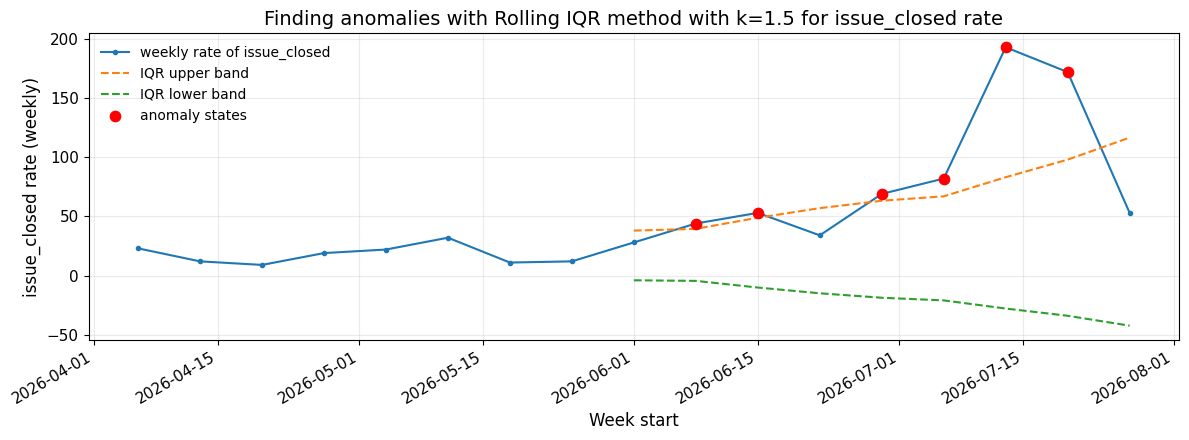

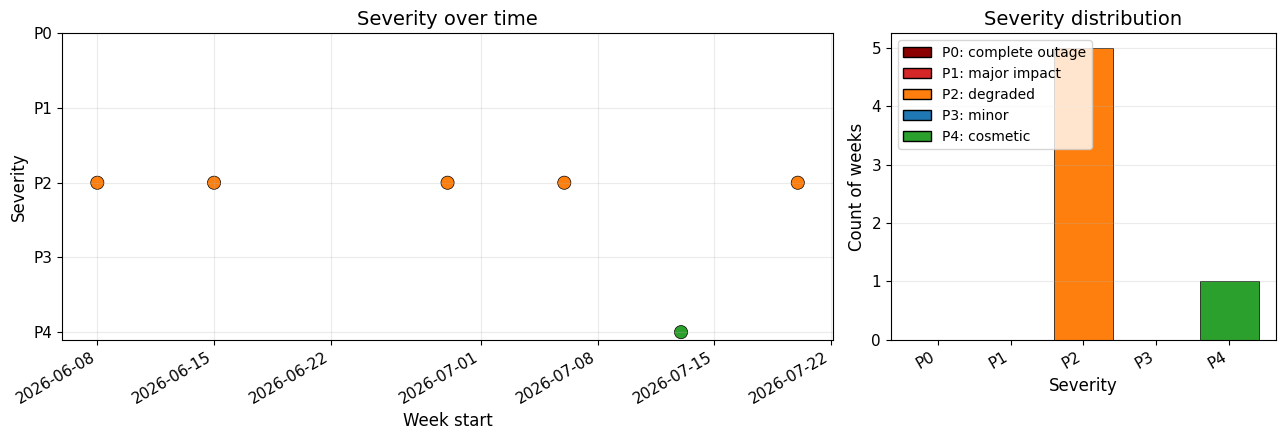

c:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:397: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.78, 1])


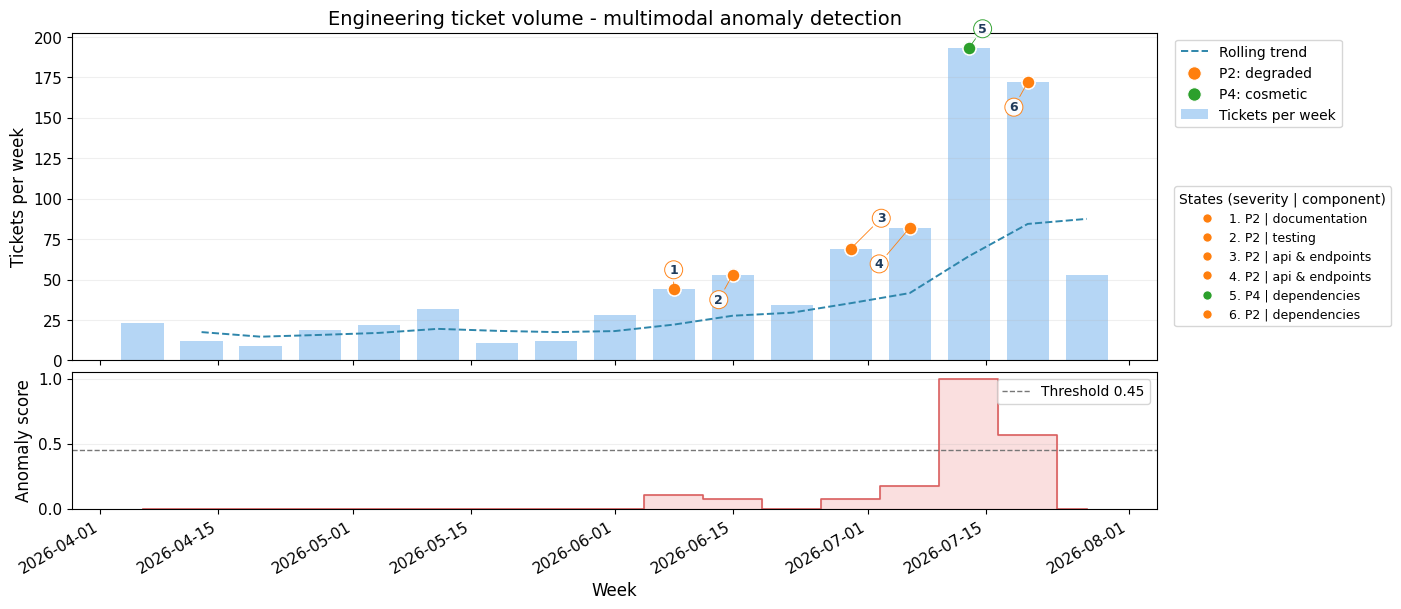

c:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:512: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.78, 0.985])


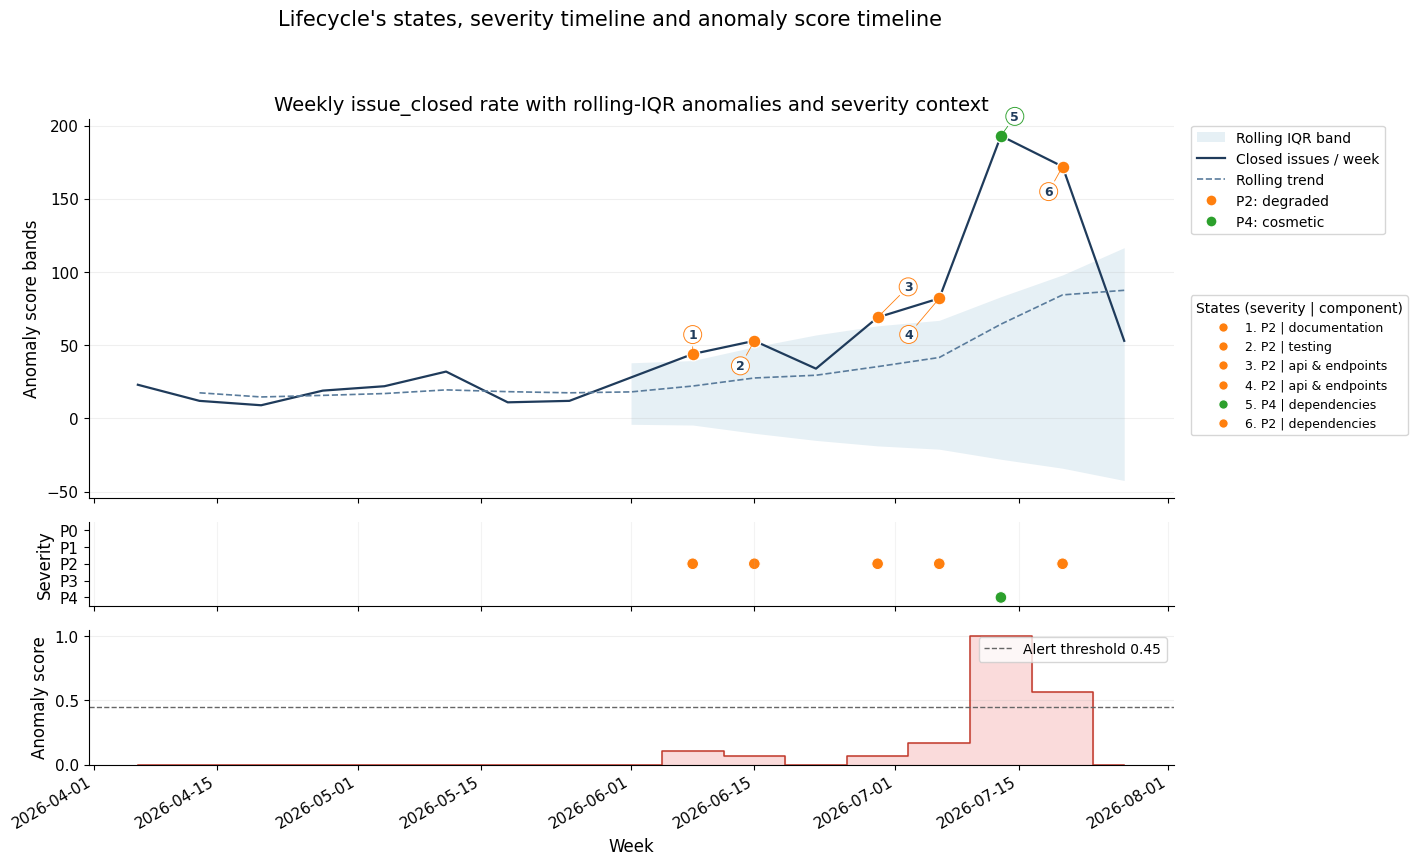

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/Vibe-Trading')

In [4]:
from functions.plotting_anomaly import plot_anomaly_figures

plot_anomaly_figures(weekly_closed_anomaly_frame, anomaly_states, cfg)


## 5. Commit context and type classification


commit_context summary: 6 rows x 17 columns
Saved commit_context to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\Vibe-Trading\commit_context.csv
commit_typeclass_per_week summary: 6 rows x 33 columns

Mean category ratios across all anomaly weeks:
  feature_work  0.200
  bug_fixes     0.348
  tech_debt     0.143
  docs          0.090
  other         0.218

Mean category ratios by anomaly_direction:
  [high] feature_work=0.200  bug_fixes=0.348  tech_debt=0.143  docs=0.090  other=0.218

Saved commit_typeclass_per_week to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\Vibe-Trading\commit_typeclass_per_week.csv


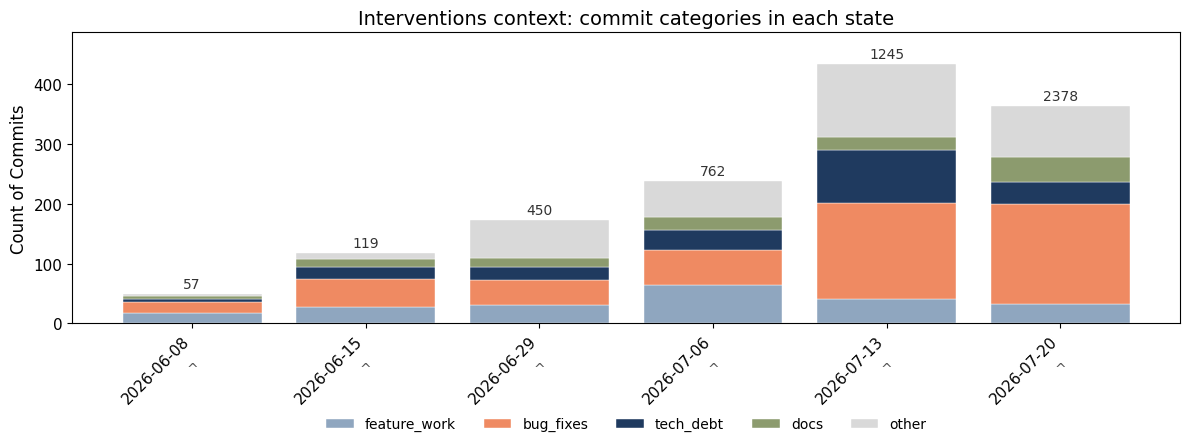

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/Vibe-Trading')

In [5]:
from functions.commits import build_commit_context, build_commit_typeclass
from functions.plotting_anomaly import plot_commit_category_stack

commit_context, event_commit_message_join = build_commit_context(
    weekly_closed_anomaly_frame, eventsPerobj_df, objects_attributes, cfg
)
commit_typeclass_per_week = build_commit_typeclass(commit_context, cfg)
plot_commit_category_stack(commit_context, commit_typeclass_per_week, cfg)


## 6. Flatten OCEL2 issue log


In [6]:
from functions.ocel_flatten import flatten_ocel2_issue_log

flat = flatten_ocel2_issue_log(cfg)


Flattened log: 12905 events, 859 cases
  case:concept:name concept:name            time:timestamp
0             10192    committed 2026-07-20 10:31:33+00:00
1             10192    committed 2026-07-20 10:31:33+00:00
2             10192    committed 2026-07-20 10:32:08+00:00
3             10192    committed 2026-07-20 10:33:20+00:00
4             10192    committed 2026-07-20 10:37:45+00:00
5             10192    committed 2026-07-20 10:39:21+00:00
6             10192    committed 2026-07-20 10:42:41+00:00
7             10192    committed 2026-07-20 10:44:45+00:00
8             10192    committed 2026-07-20 10:45:20+00:00
9             10192    committed 2026-07-20 10:48:32+00:00


## 7. Vitalizing subset from anomaly object IDs


In [7]:
from functions.ocel_flatten import build_vitalizing_subset

anomaly_events_df, anomaly_df = build_vitalizing_subset(flat, anomaly_object_ids)


Anomaly events df: 5931 rows, 611 cases


## 8. Preprocess + random control (MAX_REP / SEED unchanged)


In [8]:
from functions.preprocessing import build_preprocessed_logs

prep = build_preprocessed_logs(flat, anomaly_events_df, cfg)
flat_df_clean = prep["flat_df_clean"]
vitalizing_df_clean = prep["vitalizing_df_clean"]
random_case_control_df_clean = prep["random_case_control_df_clean"]
clean_log_groups_df = prep["clean_log_groups_df"]
all_cases_clean = prep["all_cases_clean"]
num_vital_cases_clean = prep["num_vital_cases_clean"]


=== Repetition cleaning summary (MAX_REP = 5) ===
Vitalizing: 146 -> 124 cases | 1291 -> 654 events
Whole: 210 -> 169 cases | 4920 -> 954 events
Random control (rebuilt): 124 cases | 682 events


## 9. Discovery F1 evaluation on clean logs


In [9]:
from functions.discovery import evaluate_clean_logs

consolidated_results_table_clean, clean_log_groups_eventlog, miners = evaluate_clean_logs(
    clean_log_groups_df, cfg
)
consolidated_results_table_clean.head()


c:\Users\mahsa.choopannezhadm\anaconda3\envs\LCP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
replaying log with TBR, completed traces :: 100%|██████████| 64/64 [00:00<00:00, 1230.37it/s]

Expected records: 51 | Observed: 51

7) Consolidated results table in clean logs
               log_name             discovery_method  distinct_traces  \
0   random_case_control                alpha_classic               64   
1            vitalizing                alpha_classic               53   
2                 whole                alpha_classic               82   
3   random_case_control           heuristics_dep_0.5               64   
4            vitalizing           heuristics_dep_0.5               53   
5                 whole           heuristics_dep_0.5               82   
6   random_case_control           heuristics_dep_0.6               64   
7            vitalizing           heuristics_dep_0.6               53   
8                 whole           heuristics_dep_0.6               82   
9   random_case_control           heuristics_dep_0.7               64   
10           vitalizing           heuristics_dep_0.7               53   
11                whole           heuristic

,log_name,discovery_method,distinct_traces,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,random_case_control,alpha_classic,64,0.606678,0.572686,0.192969,0.288669,74.0,8.0,0.615385,ok,None
1,vitalizing,alpha_classic,53,0.595170,0.601880,0.201221,0.301609,69.0,9.0,0.688889,ok,None
2,whole,alpha_classic,82,0.625420,0.511100,0.222360,0.309896,130.0,20.0,0.343750,ok,None
3,random_case_control,heuristics_dep_0.5,64,0.494419,0.843224,0.608136,0.706640,272.0,17.0,0.490909,ok,None
4,vitalizing,heuristics_dep_0.5,53,0.498127,0.829865,0.604448,0.699443,230.0,13.0,0.500000,ok,None


## 10. Utility figures


Plotting from 51 successful rows
Miner configs: ['alpha_classic', 'heuristics_dep_0.5', 'heuristics_dep_0.6', 'heuristics_dep_0.7', 'inductive_IM', 'inductive_IMf_noise_0.2', 'inductive_IMf_noise_0.3', 'inductive_IMf_noise_0.4', 'split_miner_eps_0.1_eta_0.4', 'split_miner_eps_0.1_eta_0.5', 'split_miner_eps_0.1_eta_0.6', 'split_miner_eps_0.2_eta_0.4', 'split_miner_eps_0.2_eta_0.5', 'split_miner_eps_0.2_eta_0.6', 'split_miner_eps_0.3_eta_0.4', 'split_miner_eps_0.3_eta_0.5', 'split_miner_eps_0.3_eta_0.6']
Log groups: ['random_case_control', 'vitalizing', 'whole']
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\Vibe-Trading\clean_log_f_score_grouped_bars.{png,pdf}


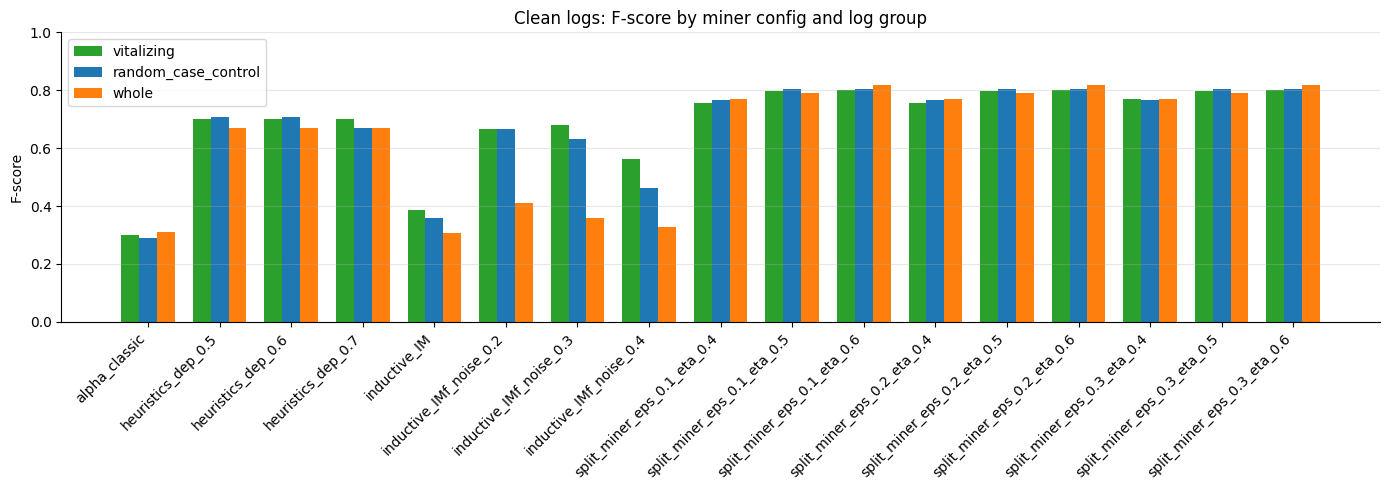

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\Vibe-Trading\clean_log_fitness_precision.{png,pdf}


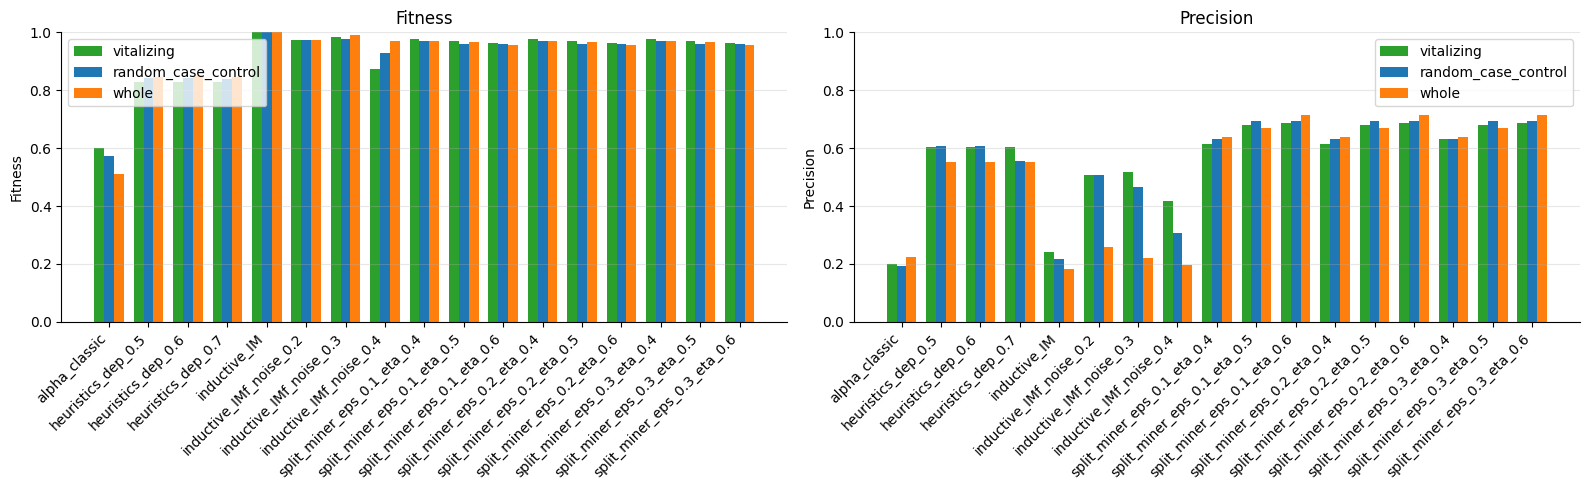

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\Vibe-Trading\clean_log_complexity.{png,pdf}


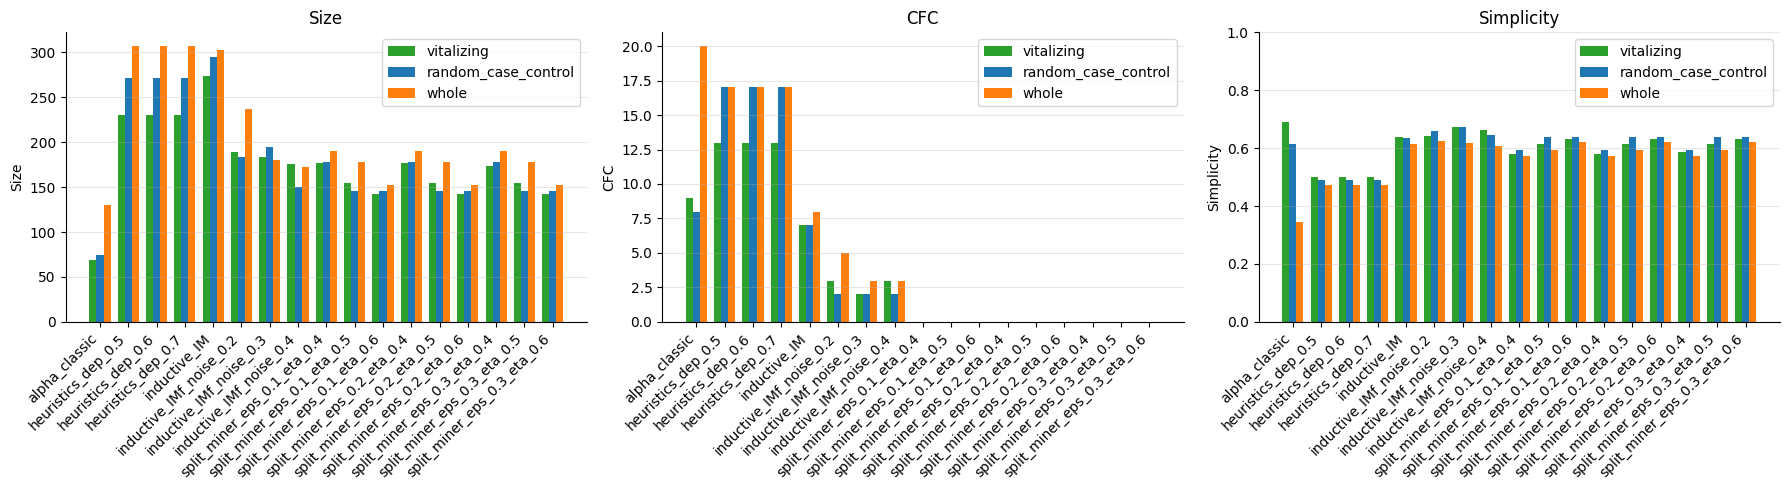

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\Vibe-Trading\clean_log_threshold_sensitivity.{png,pdf}


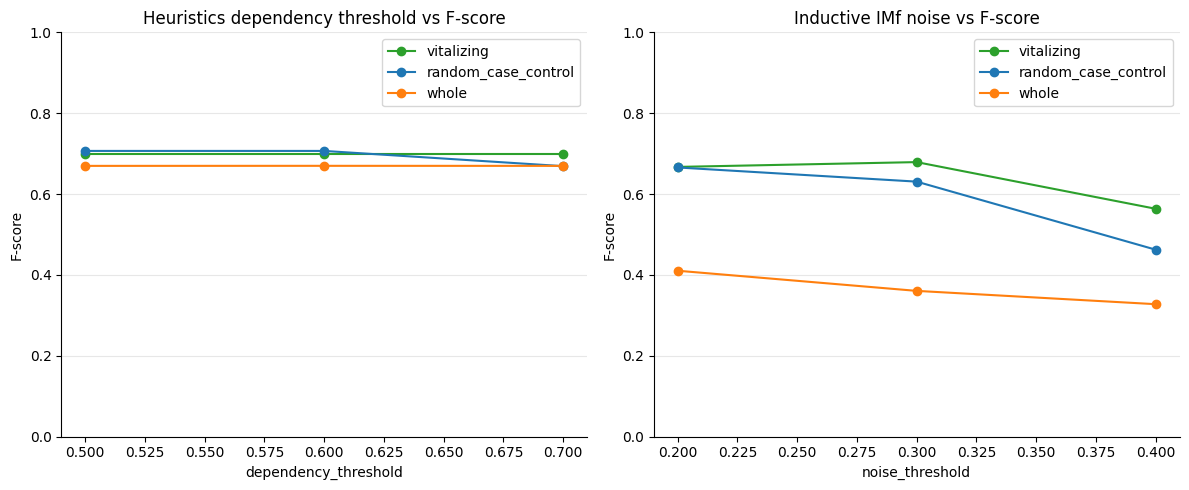

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\Vibe-Trading\clean_log_f_score_slopegraph.{png,pdf}


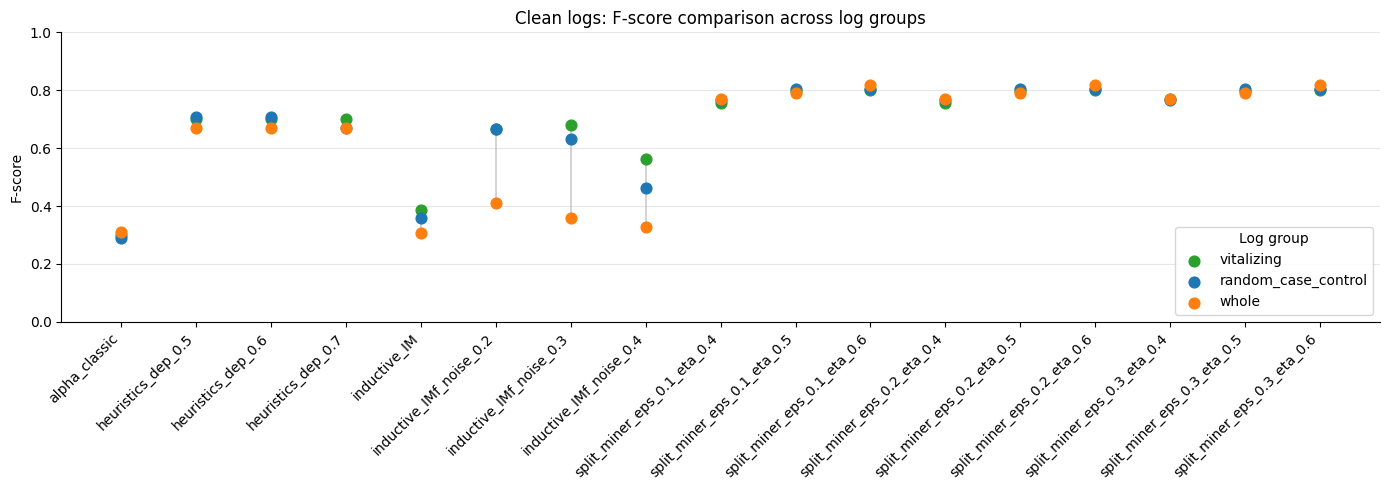

{'wide_f_score_clean': discovery_method     alpha_classic  heuristics_dep_0.5  heuristics_dep_0.6  \
 log_name                                                                     
 random_case_control       0.288669            0.706640            0.706640   
 vitalizing                0.301609            0.699443            0.699443   
 whole                     0.309896            0.669646            0.669781   
 
 discovery_method     heuristics_dep_0.7  inductive_IM  \
 log_name                                                
 random_case_control            0.668959      0.358418   
 vitalizing                     0.699443      0.386776   
 whole                          0.669646      0.308300   
 
 discovery_method     inductive_IMf_noise_0.2  inductive_IMf_noise_0.3  \
 log_name                                                                
 random_case_control                 0.665731                 0.630688   
 vitalizing                          0.667098                 0.678

In [10]:
from functions.plotting_utility import plot_utility_figures

plot_utility_figures(consolidated_results_table_clean, cfg)


## 11. Seed reproducibility


replaying log with TBR, completed traces :: 100%|██████████| 62/62 [00:00<00:00, 1366.57it/s]


Reproducibility over 10 seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Discovery metrics summary (mean/std/CV per miner):
               discovery_method  fitness_mean  fitness_std  fitness_cv  \
0                 alpha_classic      0.554859     0.040664    0.073287   
1            heuristics_dep_0.5      0.847348     0.008786    0.010369   
2            heuristics_dep_0.6      0.847675     0.008271    0.009757   
3            heuristics_dep_0.7      0.847015     0.008973    0.010594   
4                  inductive_IM      1.000000     0.000000    0.000000   
5       inductive_IMf_noise_0.2      0.975916     0.005471    0.005606   
6       inductive_IMf_noise_0.3      0.950129     0.030962    0.032588   
7       inductive_IMf_noise_0.4      0.931364     0.021172    0.022732   
8   split_miner_eps_0.1_eta_0.4      0.969048     0.002620    0.002704   
9   split_miner_eps_0.1_eta_0.5      0.964897     0.003145    0.003260   
10  split_miner_eps_0.1_eta_0.6      0.958265     0.003951    0.004123  

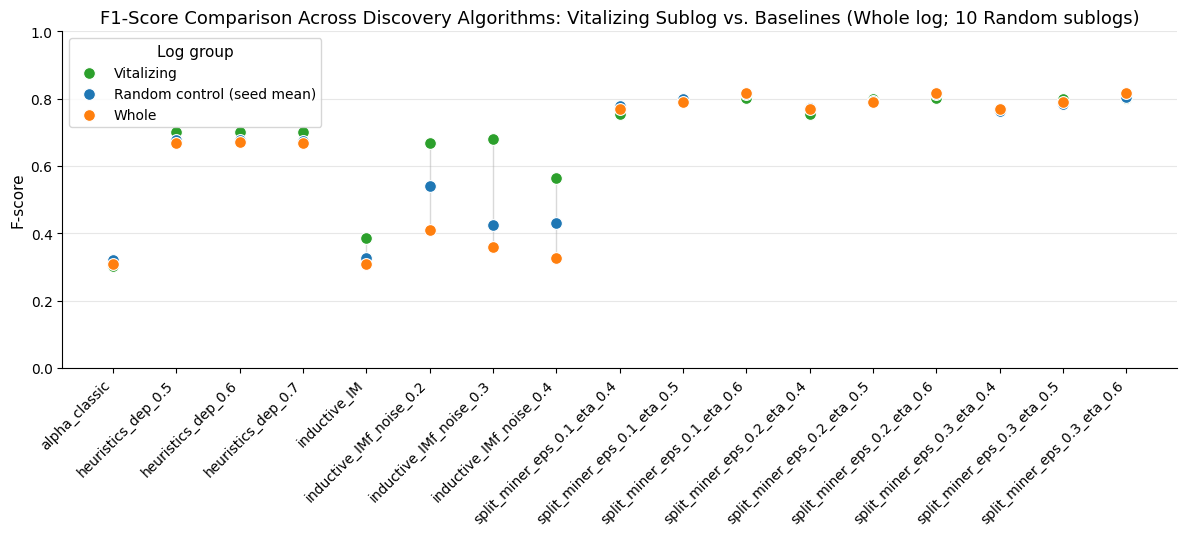

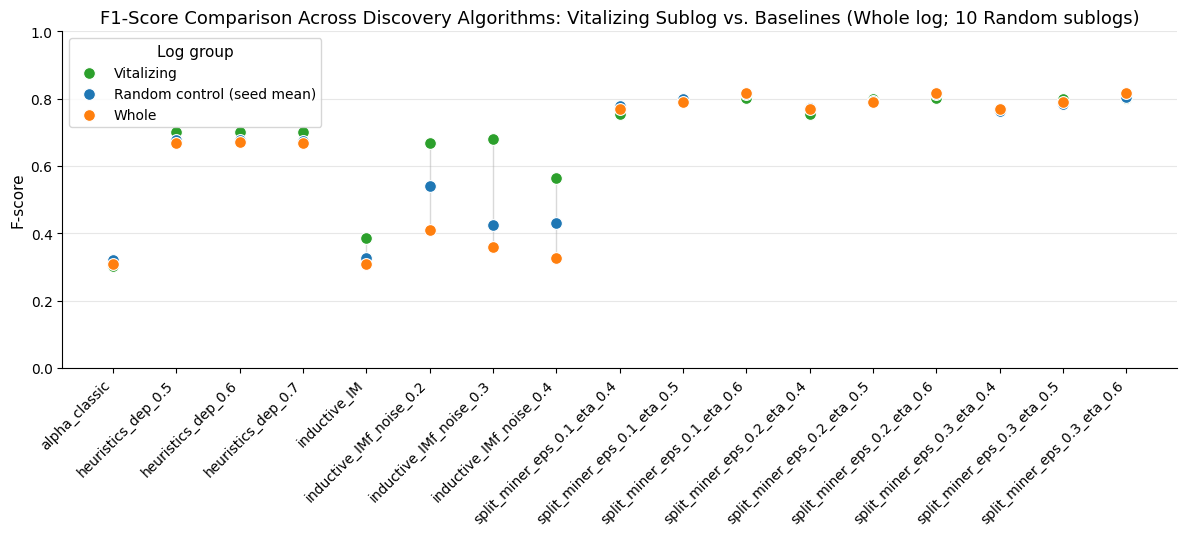

In [11]:
from functions.plotting_utility import plot_repro_slopegraph
from functions.reproducibility import run_seed_reproducibility

repro = run_seed_reproducibility(
    flat_df_clean=flat_df_clean,
    all_cases_clean=all_cases_clean,
    num_vital_cases_clean=num_vital_cases_clean,
    miners=miners,
    consolidated_results_table_clean=consolidated_results_table_clean,
    cfg=cfg,
)
consolidated_results_table_clean_repro = repro["consolidated_results_table_clean_repro"]
plot_repro_slopegraph(consolidated_results_table_clean_repro, cfg)
